# **Bioinformatics Project - Computational Drug Discovery [Part 5] Comparing Regressors**


In Part 5, we will be comparing several ML algorithms for build regression models of acetylcholinesterase inhibitors.





---

## Regression Algorithm for Molecular Descriptor–Based IC₅₀ Prediction

### What is Regression?

Regression is a **machine learning method used to predict continuous numerical values**.

In this study:

* **Input (X):** Molecular descriptors
  (numerical values describing chemical structure)
* **Output (y):** IC₅₀ value
  (a numerical measure of biological activity)

👉 Regression learns how **changes in molecular structure influence biological response**.

---

### What Are Continuous Numerical Variables?

A **continuous numerical variable** is a value that:

* Can take **any number within a range**
* Is **not limited to fixed categories**
* Can include **decimals**

#### Examples of Continuous Variables in Biology & Chemistry:

* IC₅₀ values (e.g., 0.5 µM, 1.25 µM, 10.8 µM)
* Molecular weight (e.g., 312.45 g/mol)
* logP values
* Binding energy
* Enzyme inhibition percentage

📌 **IC₅₀ is continuous** because it can take many possible values, not just fixed labels like “active” or “inactive”.

---

### Why Regression Is Used for IC₅₀ Data?

* IC₅₀ is a **continuous numerical variable**
* We want to **predict exact potency values**
* Classification cannot capture **small but biologically important differences**

✔️ Therefore, **regression** is the correct approach.

---

### How Regression Works (Simple View)

1. Each molecule is converted into **molecular descriptors**
2. The model studies how these descriptors vary with IC₅₀
3. A mathematical relationship is learned
4. The trained model predicts IC₅₀ for new molecules

🧠 Think of regression as learning:

> “If the molecular properties change like this, how does the IC₅₀ change?”

---

### Types of Regression Models (Conceptual)

Different algorithms learn patterns differently:

* **Linear Regression:** Assumes a straight-line relationship
* **Tree-based Models:** Use rule-based decisions
* **Ensemble Models:** Combine multiple learners
* **Distance-based Models:** Predict based on similarity to known compounds

⚠️ No single model is best for all biological datasets.

---

### Why Use `LazyPredict`?

`LazyPredict`:

* Trains **multiple regression models automatically**
* Uses default settings
* Compares their performance quickly

📊 It helps identify:

> Which regression algorithm best predicts IC₅₀ from molecular descriptors?

This approach is ideal for **biology students**, as it:

* Reduces coding complexity
* Focuses on **biological interpretation**

---

### How Do We Evaluate Regression Models?

Models are evaluated using:

* **R² (R-squared):**
  Measures how well the model explains IC₅₀ variation
* **MAE / RMSE:**
  Measures prediction error

✔️ A good model has:

* High R²
* Low error values

---

### Biological Interpretation

* Good regression performance suggests a strong **structure–activity relationship (SAR)**
* Helps predict biological potency **before lab experiments**
* Supports drug discovery and molecular screening

---

### Key Takeaway for Students

* **Continuous numerical variables** can take many values (like IC₅₀)
* Regression predicts these values from molecular descriptors
* `LazyPredict` compares many regression models efficiently
* The aim is to link **chemical structure to biological activity**

---



## **1. Import libraries**

In [16]:
! pip install lazypredict


---

### Explanation of the Imported Libraries

* **`pandas`**
  Used to handle and organize data in tables (rows and columns), similar to an Excel sheet.
  We use it to store **molecular descriptors and IC₅₀ values**.

* **`seaborn`**
  A visualization library used to create **graphs and plots**.
  It helps in **visualizing patterns and relationships** in the data.

* **`train_test_split` (from scikit-learn)**
  Splits the dataset into:

  * **Training data:** used to teach the model
  * **Testing data:** used to evaluate model performance
    This ensures the model can predict **new, unseen molecules**.

* **`lazypredict`**
  A tool that automatically trains **multiple machine learning models**.

* **`LazyRegressor`**
  A class from LazyPredict used specifically for **regression problems**,
  where the target variable is **continuous**, such as IC₅₀ values.

---



In [17]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import lazypredict
from lazypredict.Supervised import LazyRegressor

## **2. Load the data set**


In [25]:
df = pd.read_csv('chembl262_chembl2850_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')


---

### Explanation of Feature and Target Separation

```python
X = df.drop('pIC50', axis=1)
Y = df.pIC50
```

* **`X` (Input features):**
  This contains **all molecular descriptor values**.
  The column **`pIC50` is removed** because it is the value we want the model to predict.

* **`Y` (Target variable):**
  This contains only the **pIC50 values**, which represent the **biological activity** of the molecules.

📌 In machine learning terms:

* **X = chemical structure information**
* **Y = biological response**

---

### Biological Interpretation

The model learns how **molecular descriptors (structure)** influence **pIC50 (activity)** and then uses this relationship to predict activity for new compounds.

---

### Key Takeaway

* Descriptors go into **X**
* Activity (pIC50) goes into **Y**
* Regression models learn the relationship between **X → Y**

---


In [26]:
X = df.drop('pIC50', axis=1)
Y = df.pIC50

## **3. Data pre-processing**


---

### Checking the Shape of X

```python
X.shape
```

This shows the **dimensions of the input data**:

* **Rows:** number of molecules
* **Columns:** number of molecular descriptors

✔️ It helps confirm how many compounds and features are used for pIC50 prediction.


In [27]:
# Examine X dimension
X.shape

(3565, 881)


---

### Removing Low-Variance Features (Descriptors)

```python
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(0.8 * (1 - 0.8)))
X = selection.fit_transform(X)
X.shape
```

* This step **removes molecular descriptors that show very little variation** across molecules.
* Descriptors with low variation carry **little useful information** for predicting pIC50.
* Removing them:

  * Reduces noise
  * Improves model performance
  * Makes computation faster

📌 `X.shape` shows the **new reduced number of descriptors** after filtering.

---

### Key Idea for Students

Only descriptors that **change across molecules** are useful for learning structure–activity relationships.


In [28]:
# Remove low variance features
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X = selection.fit_transform(X)
X.shape

(3565, 158)


---

### Splitting Data into Training and Testing Sets

```python id="q7m3kz"
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
```

* The data is split into:

  * **80% training data** → used to train the model
  * **20% testing data** → used to evaluate performance
* This checks how well the model predicts **new, unseen molecules**.
* `random_state=42` ensures **reproducible results**.

✔️ Helps prevent overfitting and ensures reliable pIC50 prediction.


In [29]:
# Perform data splitting using 80/20 ratio
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## **4. Compare ML algorithms**


---

### Training and Comparing Regression Models Using LazyPredict

```python id="p3k9lm"
clf = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, Y_train, Y_test)
```

* **`LazyRegressor`** automatically trains **multiple regression algorithms**.
* Each model learns the relationship between **molecular descriptors (X)** and **pIC50 (Y)**.
* Models are then **evaluated on the test data**.
* The output:

  * **`models`** → performance comparison of all regressors
  * **`predictions`** → predicted pIC50 values

✔️ This allows quick identification of the **best regression model** for IC₅₀ prediction without manual tuning.


In [30]:
# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, Y_train, Y_test)


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 474
[LightGBM] [Info] Number of data points in the train set: 2852, number of used features: 158
[LightGBM] [Info] Start training from score 6.167905



---

### Interpretation of Regression Model Comparison

The table compares different regression models for predicting **pIC50** from **molecular descriptors**.

#### Understanding the Metrics

* **R-Squared (R²):**
  Shows how well the model explains variation in pIC50
  *(Higher = better)*

* **Adjusted R-Squared:**
  Similar to R² but penalizes unnecessary descriptors
  *(More reliable for high-dimensional data)*

* **RMSE (Root Mean Square Error):**
  Average prediction error in pIC50 units
  *(Lower = better)*

* **Time Taken:**
  Computational time required to train the model

---

### Key Observations

* **LGBMRegressor** performed best overall

  * Highest R² (0.55)
  * Lowest RMSE (0.93)
  * Fast computation

* Other strong models include:

  * **HistGradientBoostingRegressor**
  * **RandomForestRegressor**
  * **XGBRegressor**

* **Tree-based and boosting models** outperform linear models, indicating:

  > The relationship between molecular descriptors and pIC50 is **non-linear**

---

### Biological Interpretation

* Molecular structure–activity relationships are **complex**
* Advanced models capture **subtle interactions between descriptors**
* Linear models perform poorly because biological activity is **not linearly dependent** on structure

---

### Key Takeaway for Students

✔️ Boosting and ensemble models are more suitable for **IC₅₀ prediction**
✔️ LazyPredict helps quickly identify the **most biologically relevant model**
✔️ LGBMRegressor is the **best candidate** for further optimization and validation

---



In [31]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.42,0.55,0.93,0.49
HistGradientBoostingRegressor,0.40,0.53,0.95,1.04
RandomForestRegressor,0.38,0.51,0.97,4.68
XGBRegressor,0.35,0.50,0.99,0.41
NuSVR,0.35,0.49,0.99,0.96
MLPRegressor,0.34,0.49,0.99,7.03
SVR,0.34,0.49,1.00,1.14
BaggingRegressor,0.33,0.48,1.00,0.60
KNeighborsRegressor,0.30,0.46,1.02,0.09



---

### Interpretation of `predictions` Output (Regression Model Performance)

This table compares how well different regression models **predict pIC50 values** from molecular descriptors.

#### How to Read the Results

* **R-Squared (R²):**
  Measures how much variation in pIC50 is explained by the model
  *(Higher = better)*

* **Adjusted R-Squared:**
  More reliable for descriptor-rich datasets
  *(Accounts for unnecessary features)*

* **RMSE:**
  Average prediction error in pIC50 units
  *(Lower = better)*

* **Time Taken:**
  Training time for each model

---

### Key Observations

* **LGBMRegressor** shows the best overall performance

  * Highest R² (0.55)
  * Lowest RMSE (0.93)
  * Efficient training time

* **Other strong performers:**

  * HistGradientBoostingRegressor
  * RandomForestRegressor
  * XGBRegressor

* **Linear models** (LinearRegression, Ridge, Lasso) show **lower performance**, suggesting:

  > The relationship between molecular descriptors and pIC50 is **non-linear**

* **Negative R² values** indicate models that perform **worse than a simple mean prediction**, and are **not suitable** for this dataset.

---

### Biological Interpretation

* IC₅₀ depends on **complex interactions** between molecular features
* **Tree-based and boosting models** better capture these structure–activity relationships
* Simple linear assumptions fail to model biological complexity

---

### Key Takeaway for Students

✔️ Ensemble and boosting models are best for **IC₅₀ prediction**
✔️ LazyPredict helps quickly **screen and rank models**
✔️ LGBMRegressor is the **best candidate for further optimization and validation**

---


In [32]:
predictions

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.42,0.55,0.93,0.49
HistGradientBoostingRegressor,0.40,0.53,0.95,1.04
RandomForestRegressor,0.38,0.51,0.97,4.68
XGBRegressor,0.35,0.50,0.99,0.41
NuSVR,0.35,0.49,0.99,0.96
MLPRegressor,0.34,0.49,0.99,7.03
SVR,0.34,0.49,1.00,1.14
BaggingRegressor,0.33,0.48,1.00,0.60
KNeighborsRegressor,0.30,0.46,1.02,0.09


In [33]:
# Performance table of the training set (80% subset)
save_1= models
save_1.to_csv('Performance of table training set(80%).csv')
save_1

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.42,0.55,0.93,0.49
HistGradientBoostingRegressor,0.40,0.53,0.95,1.04
RandomForestRegressor,0.38,0.51,0.97,4.68
XGBRegressor,0.35,0.50,0.99,0.41
NuSVR,0.35,0.49,0.99,0.96
MLPRegressor,0.34,0.49,0.99,7.03
SVR,0.34,0.49,1.00,1.14
BaggingRegressor,0.33,0.48,1.00,0.60
KNeighborsRegressor,0.30,0.46,1.02,0.09


In [34]:
# Performance table of the test set (20% subset)
save_2= predictions
save_2.to_csv('Performance of table test set(20%).csv')
save_2

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
LGBMRegressor,0.42,0.55,0.93,0.49
HistGradientBoostingRegressor,0.40,0.53,0.95,1.04
RandomForestRegressor,0.38,0.51,0.97,4.68
XGBRegressor,0.35,0.50,0.99,0.41
NuSVR,0.35,0.49,0.99,0.96
MLPRegressor,0.34,0.49,0.99,7.03
SVR,0.34,0.49,1.00,1.14
BaggingRegressor,0.33,0.48,1.00,0.60
KNeighborsRegressor,0.30,0.46,1.02,0.09


## **5. Data visualization of model performance**

[(0.0, 1.0)]

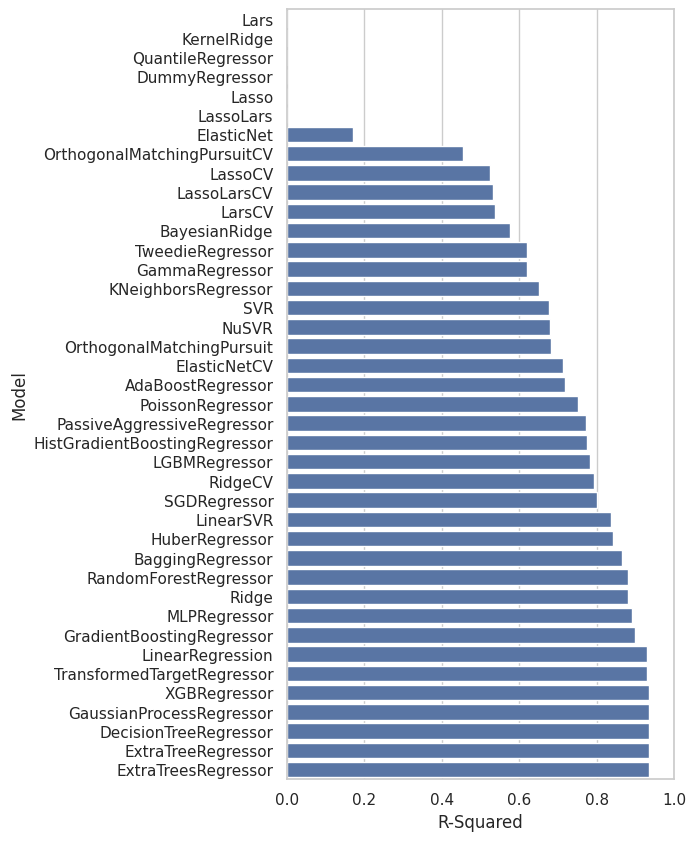

In [35]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="R-Squared", data=predictions_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

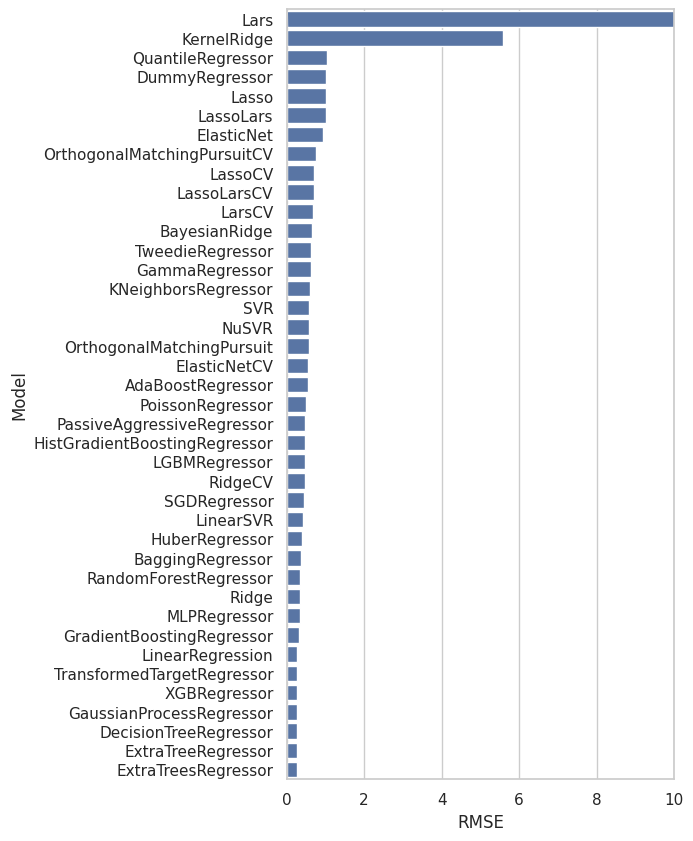

In [36]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="RMSE", data=predictions_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

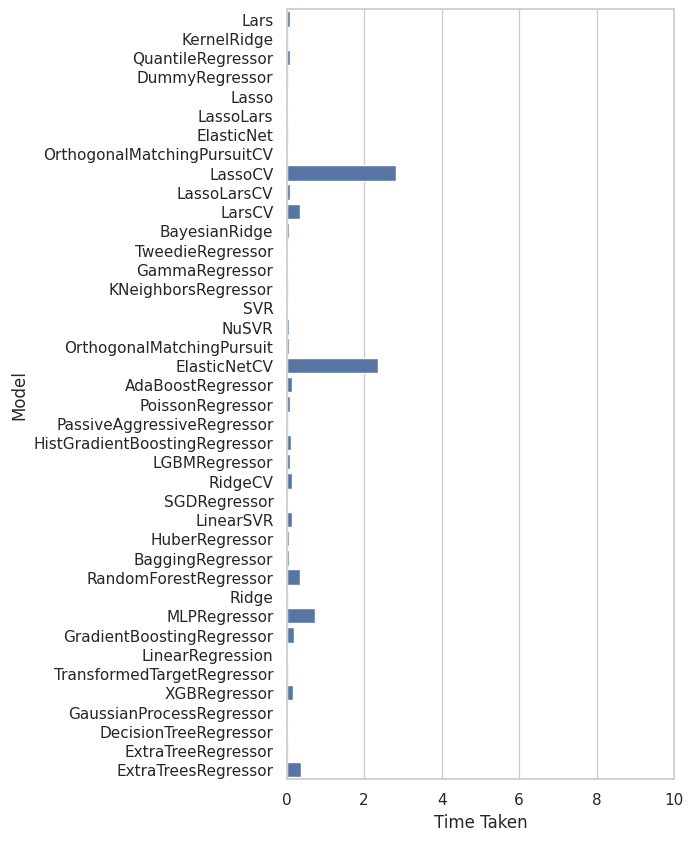

In [37]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=predictions_train.index, x="Time Taken", data=predictions_train)
ax.set(xlim=(0, 10))